In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/datasets_aligned"

print("BASE_PATH exists:", os.path.exists(BASE_PATH))
print("Files in folder:")
print(os.listdir(BASE_PATH))

BASE_PATH exists: True
Files in folder:
['NASDAQCOM.csv', 'DFF_interest_rate.csv', 'CPIAUCSL.csv', 'GDPC1.csv', 'data_gpr_daily_recent.CSV']


In [4]:
import pandas as pd

nasdaq = pd.read_csv(f"{BASE_PATH}/NASDAQCOM.csv")
cpi = pd.read_csv(f"{BASE_PATH}/CPIAUCSL.csv")
gdp = pd.read_csv(f"{BASE_PATH}/GDPC1.csv")
rate = pd.read_csv(f"{BASE_PATH}/DFF_interest_rate.csv")
gpr = pd.read_csv(f"{BASE_PATH}/data_gpr_daily_recent.CSV")

In [ ]:
print("NASDAQ columns:", nasdaq.columns.tolist())
print("CPI columns:", cpi.columns.tolist())
print("GDP columns:", gdp.columns.tolist())
print("Rate columns:", rate.columns.tolist())
print("GPR columns:", gpr.columns.tolist())

NASDAQ columns: ['date', 'NASDAQCOM']
CPI columns: ['date', 'cpi']
GDP columns: ['date', 'GDP']
Rate columns: ['date', 'DFF']
GPR columns: ['date', 'gpr']


In [ ]:
nasdaq["date"] = pd.to_datetime(nasdaq["date"])
cpi["date"] = pd.to_datetime(cpi["date"])
gdp["date"] = pd.to_datetime(gdp["date"])
rate["date"] = pd.to_datetime(rate["date"])
gpr["date"] = pd.to_datetime(gpr["date"])

nasdaq = nasdaq.rename(columns={"NASDAQCOM": "nasdaq"})
cpi = cpi.rename(columns={"CPIAUCSL": "cpi"})
gdp = gdp.rename(columns={"GDP": "gdp"})
rate = rate.rename(columns={"DFF": "interest_rate"})

if "GPRD_MA7" in gpr.columns:
    gpr = gpr.rename(columns={"GPRD_MA7": "gpr"})
elif "gpr" in gpr.columns:
    pass
else:
    raise ValueError(f"Cannot find GPR column. Columns are: {gpr.columns.tolist()}")

gpr = gpr[["date", "gpr"]]

print("After rename:")
print("NASDAQ:", nasdaq.columns.tolist())
print("CPI:", cpi.columns.tolist())
print("GDP:", gdp.columns.tolist())
print("Rate:", rate.columns.tolist())
print("GPR:", gpr.columns.tolist())

After rename:
NASDAQ: ['date', 'nasdaq']
CPI: ['date', 'cpi']
GDP: ['date', 'gdp']
Rate: ['date', 'interest_rate']
GPR: ['date', 'gpr']


In [7]:
df = nasdaq.merge(cpi, on="date", how="inner")
df = df.merge(gdp, on="date", how="inner")
df = df.merge(rate, on="date", how="inner")
df = df.merge(gpr, on="date", how="inner")

df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print(df.tail())
print("Shape:", df.shape)

        date  nasdaq    cpi      gdp  interest_rate     gpr
0 1985-01-01  246.63  105.7  8400.82           8.74  230.04
1 1985-01-02  245.91  105.7  8400.82           9.37  172.86
2 1985-01-03  246.41  105.7  8400.82           8.77  147.71
3 1985-01-04  246.19  105.7  8400.82           8.18  150.13
4 1985-01-05  246.14  105.7  8400.82           8.18  136.37
            date        nasdaq      cpi        gdp  interest_rate     gpr
14879 2025-09-27  22519.763333  324.245  24026.834           4.09  117.21
14880 2025-09-28  22555.456667  324.245  24026.834           4.09  112.72
14881 2025-09-29  22591.150000  324.245  24026.834           4.09  111.93
14882 2025-09-30  22660.010000  324.245  24026.834           4.09  116.06
14883 2025-10-01  22755.160000  324.245  24065.956           4.09  121.91
Shape: (14884, 6)


In [8]:
df = df.copy()

# same target style as baseline
df["return"] = df["nasdaq"].pct_change() * 10

# dynamic external feature
df["rate_change"] = df["interest_rate"].diff()

# next-day return target
df["target"] = df["return"].shift(-1)

df = df.dropna().reset_index(drop=True)

# BEST compact feature set
seq_feature_cols = [
    "return",
    "gpr",
    "rate_change",
]

print(df[["date", "target"] + seq_feature_cols].head())
print(df.shape)

        date    target    return     gpr  rate_change
0 1985-01-02  0.020333 -0.029194  172.86         0.63
1 1985-01-03 -0.008928  0.020333  147.71        -0.60
2 1985-01-04 -0.002031 -0.008928  150.13        -0.59
3 1985-01-05 -0.002031 -0.002031  136.37         0.00
4 1985-01-06 -0.002032 -0.002031  141.53         0.00
(14882, 9)


In [ ]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.9
WINDOW_SIZE = 60

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * VAL_RATIO)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 11905
Val size: 1488
Test size: 1489


In [ ]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[seq_feature_cols])
val_scaled = scaler.transform(val_df[seq_feature_cols])
test_scaled = scaler.transform(test_df[seq_feature_cols])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[seq_feature_cols] = train_scaled
val_df_scaled[seq_feature_cols] = val_scaled
test_df_scaled[seq_feature_cols] = test_scaled

In [ ]:
class MultiFeatureSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, window_size=60):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.window_size = window_size

        self.X = self.df[feature_cols].values.astype(np.float32)
        self.y = self.df["target"].values.astype(np.float32)

    def __len__(self):
        return len(self.df) - self.window_size

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y = self.y[idx + self.window_size - 1]

        x_seq = torch.tensor(x_seq)
        y = torch.tensor(y)

        return x_seq, y

In [ ]:
BATCH_SIZE = 128

train_dataset = MultiFeatureSequenceDataset(train_df_scaled, seq_feature_cols, WINDOW_SIZE)
val_dataset = MultiFeatureSequenceDataset(val_df_scaled, seq_feature_cols, WINDOW_SIZE)
test_dataset = MultiFeatureSequenceDataset(test_df_scaled, seq_feature_cols, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 11845
Val dataset: 1428
Test dataset: 1429


In [ ]:
class FeatureAttention(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Tanh(),
            nn.Linear(input_size, input_size)
        )

    def forward(self, x):
        # x: (batch, window, input_size)
        scores = self.attn(x)                    # (batch, window, input_size)
        weights = torch.softmax(scores, dim=-1) # feature attention at each time step
        x_weighted = x * weights
        return x_weighted, weights


class MultiDimAttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=2, dropout=0.2, fc_hidden=64):
        super().__init__()

        self.feature_attention = FeatureAttention(input_size)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1)
        )

    def forward(self, x, return_attention=False):
        x_weighted, attn_weights = self.feature_attention(x)

        lstm_out, _ = self.lstm(x_weighted)
        last_hidden = lstm_out[:, -1, :]

        out = self.fc(last_hidden).squeeze(-1)

        if return_attention:
            return out, attn_weights
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MultiDimAttentionLSTM(
    input_size=len(seq_feature_cols),
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    fc_hidden=64
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.5,
#     patience=3
# )

Using device: cuda


In [15]:
def variance_loss(preds, targets):
    pred_var = torch.var(preds, unbiased=False)
    target_var = torch.var(targets, unbiased=False)
    return torch.abs(pred_var - target_var)

def combined_loss(preds, targets, alpha=0.5):
    mse = criterion(preds, targets)
    var = variance_loss(preds, targets)
    return mse + alpha * var

Epoch 1: Train Loss = 0.016487, Val Loss = 0.017567
Epoch 2: Train Loss = 0.016342, Val Loss = 0.017336
Epoch 3: Train Loss = 0.016447, Val Loss = 0.017549
Epoch 4: Train Loss = 0.016273, Val Loss = 0.017355
Epoch 5: Train Loss = 0.016293, Val Loss = 0.017615
Epoch 6: Train Loss = 0.016362, Val Loss = 0.017498
Epoch 7: Train Loss = 0.016275, Val Loss = 0.017390
Epoch 8: Train Loss = 0.016219, Val Loss = 0.017467
Epoch 9: Train Loss = 0.016214, Val Loss = 0.017521
Epoch 10: Train Loss = 0.016229, Val Loss = 0.017515
Epoch 11: Train Loss = 0.015989, Val Loss = 0.018127
Epoch 12: Train Loss = 0.016029, Val Loss = 0.017524
Early stopping triggered.


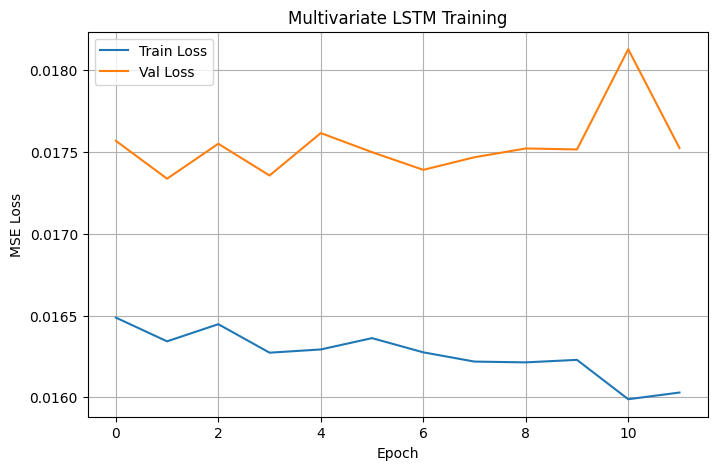

===== TEST RESULTS =====
MSE: 0.01399262
MAE: 0.07311740
Direction F1: 0.65655900
Direction Accuracy: 0.63540938


In [ ]:
EPOCHS = 50
EARLY_STOP_PATIENCE = 10

best_val_loss = float("inf")
best_state = None
no_improve = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for x_seq, y in train_loader:
        x_seq = x_seq.to(device)
        y = y.to(device)

        preds = model(x_seq)
        loss = combined_loss(preds, y, alpha=0.5)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_seq, y in val_loader:
            x_seq = x_seq.to(device)
            y = y.to(device)

            preds = model(x_seq)
            loss = combined_loss(preds, y, alpha=0.5)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    # scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f}, Val Loss = {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multivariate LSTM Training")
plt.legend()
plt.grid(True)
plt.show()

# Cell 16
def direction_accuracy(y_true, y_pred):
    y_true_dir = np.sign(y_true)
    y_pred_dir = np.sign(y_pred)
    return np.mean(y_true_dir == y_pred_dir)

def direction_f1(y_true, y_pred):
    y_true_bin = (y_true > 0).astype(int)
    y_pred_bin = (y_pred > 0).astype(int)
    return f1_score(y_true_bin, y_pred_bin)

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for x_seq, y in test_loader:
        x_seq = x_seq.to(device)
        preds = model(x_seq)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.numpy())

preds = np.concatenate(all_preds)
targets = np.concatenate(all_targets)

mse = np.mean((preds - targets) ** 2)
mae = mean_absolute_error(targets, preds)
acc = direction_accuracy(targets, preds)
f1 = direction_f1(targets, preds)

print("===== TEST RESULTS =====")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")
print(f"Direction F1: {f1:.8f}")
print(f"Direction Accuracy: {acc:.8f}")

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

# Convert returns into direction labels
true_dir = (targets > 0).astype(int)
pred_dir = (preds > 0).astype(int)

# ----- Metrics -----
auc = roc_auc_score(true_dir, preds)
corr = np.corrcoef(preds.flatten(), targets.flatten())[0, 1]
baseline = true_dir.mean()
acc = (pred_dir == true_dir).mean()
f1 = f1_score(true_dir, pred_dir)

print("===== TEST RESULTS =====")
print(f"AUC-ROC  : {auc:.4f}")
print(f"Corr     : {corr:.4f}")
print(f"Baseline : {baseline:.4f}  (naive always-up accuracy)")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")


CONF = 0.01

hc_mask = (preds > CONF) | (preds < -CONF)

if hc_mask.sum() > 0:

    hc_acc = (
        pred_dir[hc_mask] == true_dir[hc_mask]
    ).mean()

    hc_auc = roc_auc_score(
        true_dir[hc_mask],
        preds[hc_mask]
    )

    print(f"\n===== HIGH-CONFIDENCE SUBSET =====")
    print(f"Threshold : |pred return| > {CONF}")
    print(f"Coverage  : {hc_mask.mean():.1%} ({hc_mask.sum()} samples)")
    print(f"Accuracy  : {hc_acc:.4f}")
    print(f"AUC-ROC   : {hc_auc:.4f}")

===== TEST RESULTS =====
AUC-ROC  : 0.6312
Corr     : 0.0662
Baseline : 0.5465  (naive always-up accuracy)
Accuracy : 0.6354
F1 Score : 0.6566

===== HIGH-CONFIDENCE SUBSET =====
Threshold : |pred return| > 0.01
Coverage  : 72.0% (1029 samples)
Accuracy  : 0.6395
AUC-ROC   : 0.6225


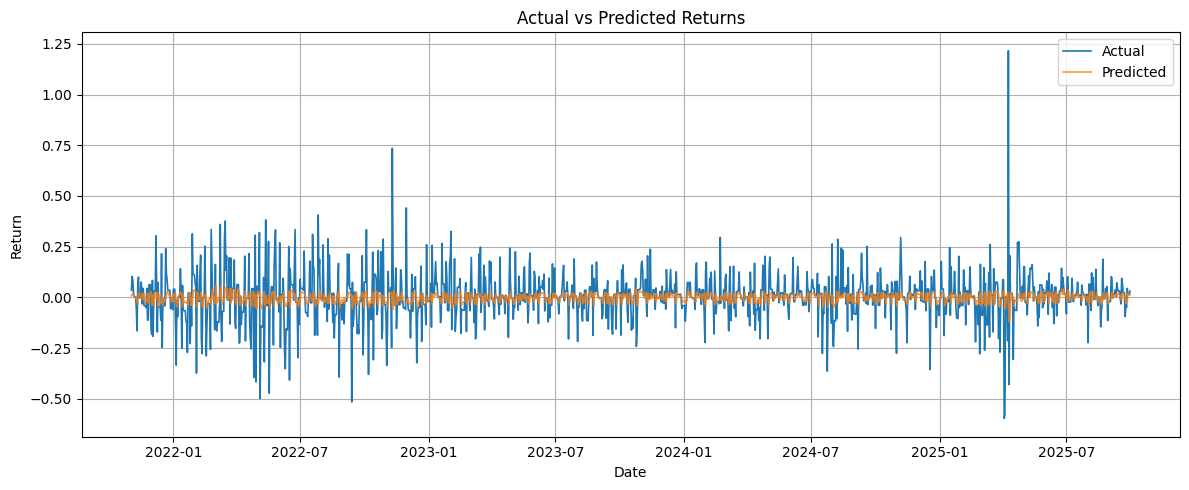

In [21]:
# Correct aligned dates
test_dates = test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(preds)]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_dates, targets, label="Actual", linewidth=1.2)
plt.plot(test_dates, preds, label="Predicted", linewidth=1.2, alpha=0.8)

plt.title("Actual vs Predicted Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

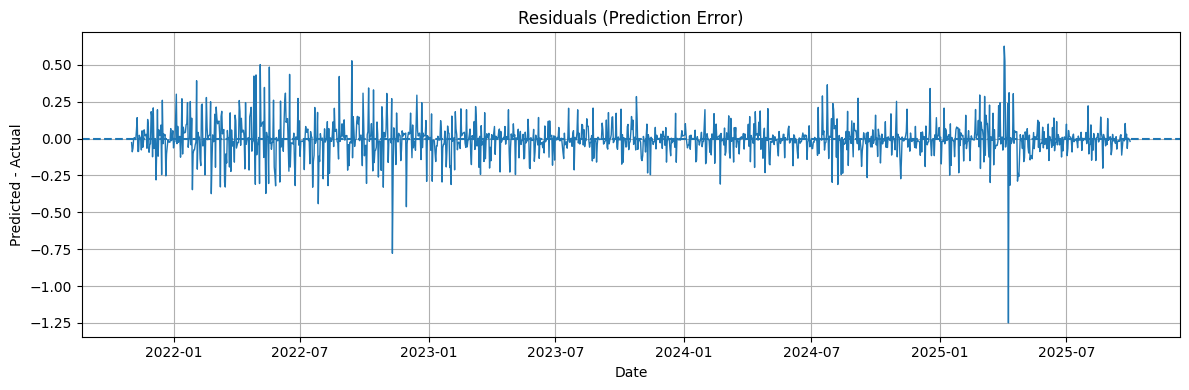

In [22]:
residuals = preds - targets

test_dates = test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(preds)]

plt.figure(figsize=(12, 4))
plt.plot(test_dates, residuals, linewidth=1.0)

plt.axhline(0, linestyle="--")
plt.title("Residuals (Prediction Error)")
plt.xlabel("Date")
plt.ylabel("Predicted - Actual")

plt.grid(True)
plt.tight_layout()
plt.show()

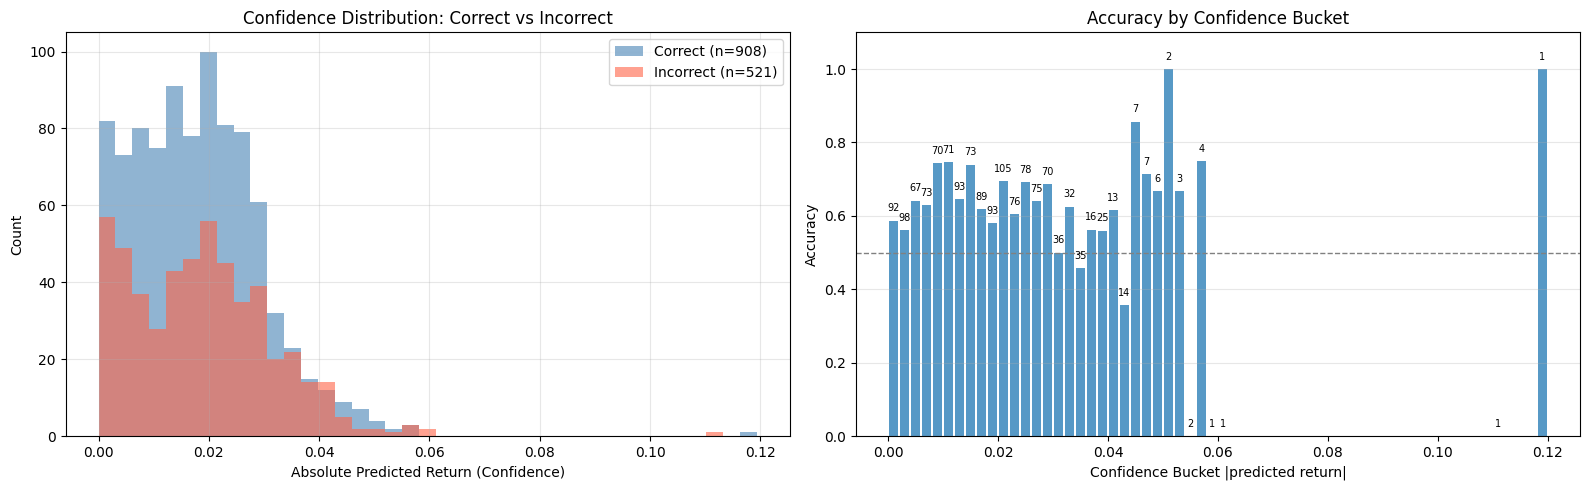

            Bucket      n  Accuracy  Bar
-------------------------------------------------------
[0.0000, 0.0020)     92     0.587  ███████████
[0.0020, 0.0040)     98     0.561  ███████████
[0.0040, 0.0060)     67     0.642  ████████████
[0.0060, 0.0080)     73     0.630  ████████████
[0.0080, 0.0100)     70     0.743  ██████████████
[0.0100, 0.0120)     71     0.746  ██████████████
[0.0120, 0.0140)     93     0.645  ████████████
[0.0140, 0.0160)     73     0.740  ██████████████
[0.0160, 0.0180)     89     0.618  ████████████
[0.0180, 0.0200)     93     0.581  ███████████
[0.0200, 0.0220)    105     0.695  █████████████
[0.0220, 0.0240)     76     0.605  ████████████
[0.0240, 0.0260)     78     0.692  █████████████
[0.0260, 0.0280)     75     0.640  ████████████
[0.0280, 0.0300)     70     0.686  █████████████
[0.0300, 0.0320)     36     0.500  ██████████
[0.0320, 0.0340)     32     0.625  ████████████
[0.0340, 0.0360)     35     0.457  █████████
[0.0360, 0.0380)     16     0.562  ███

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Direction labels
# --------------------------------------------------

true_dir = (targets > 0).astype(int)
pred_dir = (preds > 0).astype(int)

correct_mask = (pred_dir == true_dir)

# Confidence = absolute predicted return
confidence = np.abs(preds)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ==================================================
# 1. Confidence distribution
# ==================================================

bins = np.linspace(0, confidence.max(), 40)

axes[0].hist(
    confidence[correct_mask],
    bins=bins,
    alpha=0.6,
    color='steelblue',
    label=f'Correct (n={correct_mask.sum()})'
)

axes[0].hist(
    confidence[~correct_mask],
    bins=bins,
    alpha=0.6,
    color='tomato',
    label=f'Incorrect (n={(~correct_mask).sum()})'
)

axes[0].set_xlabel('Absolute Predicted Return (Confidence)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==================================================
# 2. Accuracy by confidence bucket
# ==================================================

BUCKET_WIDTH = 0.002

edges = np.arange(
    0,
    confidence.max() + BUCKET_WIDTH,
    BUCKET_WIDTH
)

centers = []
accs = []
counts = []

for lo, hi in zip(edges[:-1], edges[1:]):

    m = (confidence >= lo) & (confidence < hi)

    if m.sum() == 0:
        continue

    centers.append((lo + hi) / 2)

    accs.append(
        (pred_dir[m] == true_dir[m]).mean()
    )

    counts.append(m.sum())

bars = axes[1].bar(
    centers,
    accs,
    width=BUCKET_WIDTH * 0.85,
    alpha=0.75
)

axes[1].axhline(
    0.5,
    color='gray',
    linestyle='--',
    linewidth=1
)

# Annotate counts
for bar, n in zip(bars, counts):

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        str(n),
        ha='center',
        va='bottom',
        fontsize=7
    )

axes[1].set_xlabel('Confidence Bucket |predicted return|')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy by Confidence Bucket')

axes[1].set_ylim(0, 1.1)

axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ==================================================
# Print table
# ==================================================

print(f'{"Bucket":>18}  {"n":>5}  {"Accuracy":>8}  Bar')
print('-' * 55)

for c, n, a in zip(centers, counts, accs):

    lo = c - BUCKET_WIDTH / 2
    hi = c + BUCKET_WIDTH / 2

    bar = '█' * int(a * 20)

    print(
        f'[{lo:.4f}, {hi:.4f})  '
        f'{n:5d}  '
        f'{a:8.3f}  '
        f'{bar}'
    )